<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
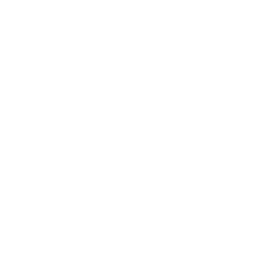
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">EWMA-trendanalys av läkemedelsfelfrekvens</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Sjukvård / Patientsäkerhet &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Den här analysen övervakar den veckovisa läkemedelsfelfrekvensen på en sjukhus-IVA (intensivvårdsavdelning) med hjälp av ett **exponentiellt viktat glidande medelvärde (EWMA)-styrdiagram** från PROC MACONTROL. IVA-avdelningen införde ett nytt elektroniskt läkemedelsadministrationssystem (eMAR) vecka 51 av observationsperioden. Patientsäkerhetsteam behöver en tidig varningsmetod som snabbt flaggar en varaktig ökning av fel, innan en fjärdedel av skaderapporterna hunnit ackumuleras.

EWMA-diagrammet med utjämningsvikt **lambda = 0,3** byggs i två faser. Styrgränserna etableras först från den stabila baslinjen före migreringen (vecka 1-50), och därefter övervakas hela 100-veckorsserien mot dessa fasta gränser. Diagrammet håller sig inom kontroll under hela baslinjen och signalerar ett utom-kontroll-tillstånd redan **första veckan efter driftsättningen**, vilket bekräftar att eMAR-övergången sammanföll med en verklig, varaktig förändring i felfrekvensen snarare än vanligt veckovis brus.

## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|--------|
| WORK.ICU_ERRORS | Veckovis läkemedelsfelfrekvens per 1 000 administreringar för en IVA-avdelning, 100 sammanhängande veckor | 100 |

En enskild IVA-avdelning följs veckovis. Varje post innehåller veckonumret, felfrekvensen per 1 000 administreringar, administreringsvolymen och det härledda antalet fel. En dokumenterad processförändring (eMAR-driftsättning) inträffar vecka 51, vilket höjer den underliggande medelfelfrekvensen med ungefär 1,6 per 1 000.

---

In [1]:
/* --------------------------------------------------------
   Generera veckovisa IVA-läkemedelsfeldata
   100 sammanhängande veckor för en IVA-avdelning.
   Ett nytt eMAR-system driftsätts vecka 51, vilket höjer
   den underliggande felfrekvensen från ~3,5 till ~5,1 per 1 000.
   -------------------------------------------------------- */
data work.icu_errors;
    CALL streaminit(42);
    LÄNGD unit_name $12 phase $12;
    unit_name = 'ICU';
    base_rate  = 3.5;   /* medelfrekvens före migrering / 1 000 */
    unit_sigma = 0.45;  /* vanligt brus vecka till vecka */
    GÖR week_num = 1 TILL 100;
        week_start_date = '01JAN2024'd + (week_num - 1) * 7;
        administrations = int(rand('normal', 800, 80));
        OM administrations < 300 SÅ administrations = 300;
        /* eMAR-migreringen höjer medelvärdet efter vecka 50 */
        OM week_num > 50 SÅ GÖR;
            phase = 'EFTER-eMAR';
            error_rate_per_1k =
                round(rand('normal', base_rate + 1.6, unit_sigma), 0.01);
        SLUT;
        ANNARS GÖR;
            phase = 'BASLINJE';
            error_rate_per_1k =
                round(rand('normal', base_rate, unit_sigma), 0.01);
        SLUT;
        OM error_rate_per_1k < 0 SÅ error_rate_per_1k = 0;
        error_count = round(administrations * error_rate_per_1k / 1000);
        UTDATA;
    SLUT;
    TA_BORT base_rate unit_sigma;
    format week_start_date date9.;
KÖR;


NOTE: DATA work.icu_errors


NOTE: Wrote work.icu_errors (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                    IVA-felfrekvens: baslinje jämfört med efter eMAR                                    

                                                  The MEANS Procedure

                      Analysis Variable : error_rate_per_1k Felfrekvens per 1 000 administreringar

        Fas                 N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        BASLINJE               50           3.50           0.48           2.55           4.71
        EFTER-eMAR             50           5.11           0.44           3.69           5.96
        -------------------------------------------------------------------------------------

                                       Analysis Variable : error_count Antal fel

        Fas                 N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.icu_errors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


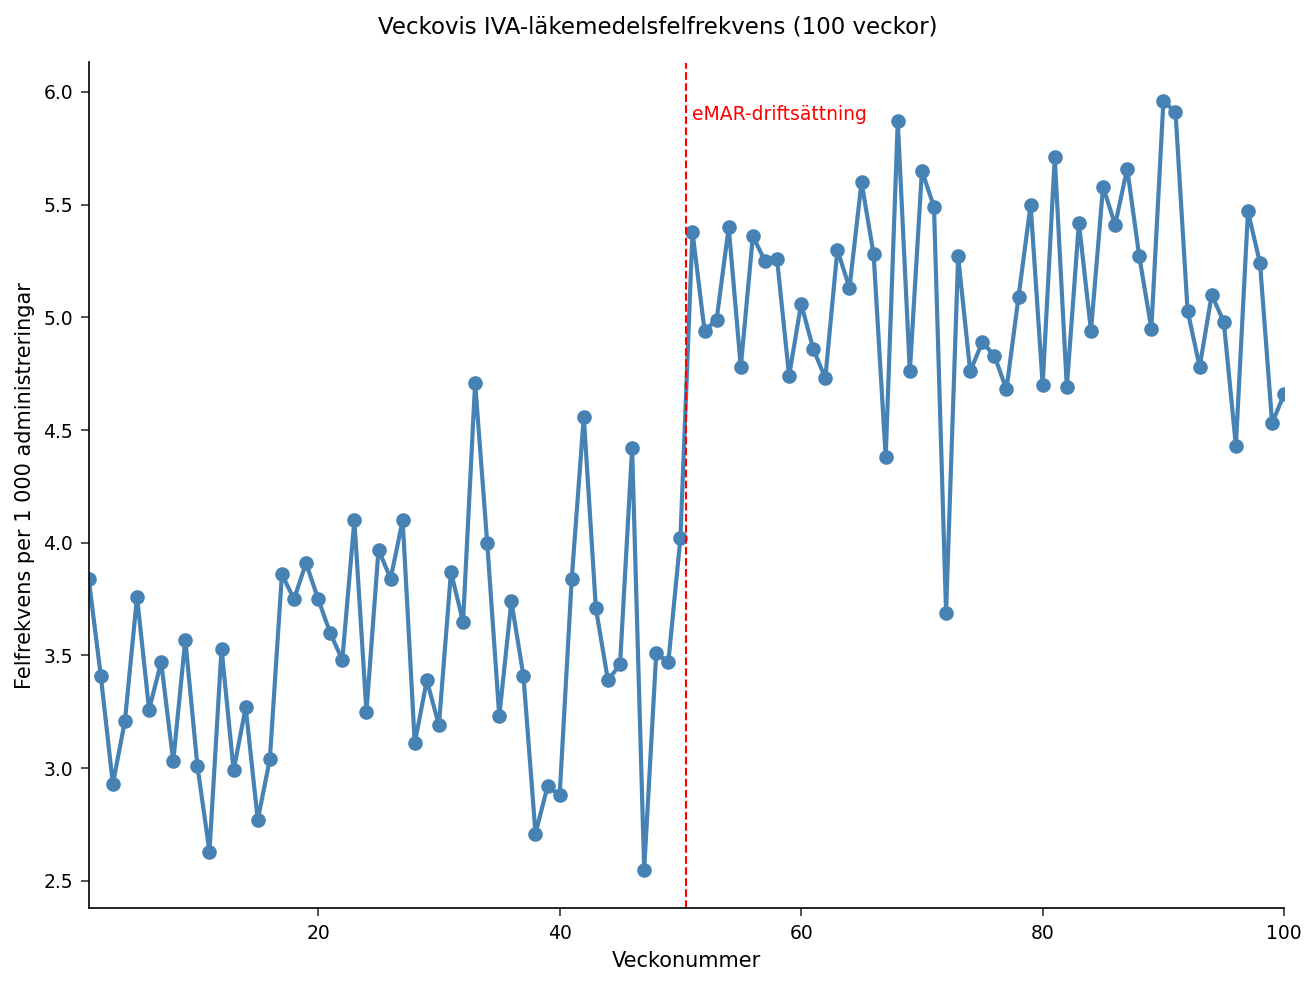

In [2]:
/* --------------------------------------------------------
   Jämför felfrekvensen före och efter eMAR-driftsättningen,
   och plotta den veckovisa trenden.
   -------------------------------------------------------- */
PROCEDUR MEDELVÄRDEN data=work.icu_errors n mean std MIN MAX maxdec=2;
    KLASS phase;
    VARIABEL error_rate_per_1k error_count administrations;
    ETIKETT phase="Fas" error_rate_per_1k="Felfrekvens per 1 000 administreringar"
          error_count="Antal fel" administrations="Administreringar";
    TITEL "IVA-felfrekvens: baslinje jämfört med efter eMAR";
KÖR;

PROCEDUR SGPLOT data=work.icu_errors;
    SERIES x=week_num y=error_rate_per_1k / MARKERS
           LINEATTRS=(color=steelblue thickness=2);
    REFLINE 50.5 / AXIS=x LINEATTRS=(color=red pattern=dash)
                   ETIKETT="eMAR-driftsättning";
    XAXIS ETIKETT="Veckonummer";
    YAXIS ETIKETT="Felfrekvens per 1 000 administreringar";
    TITEL "Veckovis IVA-läkemedelsfelfrekvens (100 veckor)";
KÖR;

---

In [3]:
/* --------------------------------------------------------
   Fas I: etablera EWMA-styrgränser från den stabila
   baslinjen före migreringen (vecka 1-50). Dessa fasta
   gränser blir måttstocken för hela övervakningsperioden.
   -------------------------------------------------------- */
PROCEDUR MEDELVÄRDEN data=work.icu_errors(DÄR=(week_num <= 50)) NOPRINT;
    VARIABEL error_rate_per_1k;
    UTDATA out=work.baseline_stats mean=base_mean std=base_std;
KÖR;

data work.icu_limits;
    STÄLL_IN work.baseline_stats;
    LÄNGD _VAR_ $32 _SUBGRP_ $32;
    _VAR_    = 'error_rate_per_1k';
    _SUBGRP_ = 'week_num';
    _MEAN_   = base_mean;   /* baslinjens centrumlinje */
    _STDDEV_ = base_std;    /* baslinjens naturliga variation (sigma) */
    _LIMITN_ = 1;
    BEHÅLL _VAR_ _SUBGRP_ _MEAN_ _STDDEV_ _LIMITN_;
KÖR;

PROCEDUR SKRIV data=work.icu_limits noobs;
    TITEL "Indata för fas I-kontrollgränser (baslinjeveckor 1-50)";
KÖR;

                                 Indata för fas I-kontrollgränser (baslinjeveckor 1-50)                                 

            _VAR_  _SUBGRP_  _MEAN_      _STDDEV_  _LIMITN_
error_rate_per_1k  week_num  3.5014  0.4829036749         1




NOTE: PROC MEANS
NOTE: Output dataset work.baseline_stats has 1 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.icu_limits


NOTE: Read 1 rows from work.baseline_stats.
NOTE: Wrote work.icu_limits (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.icu_limits

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

                                 Indata för fas I-kontrollgränser (baslinjeveckor 1-50)                                 


                    The MACONTROL Procedure
                    EWMA Chart (lambda=0.30)
  Variable:       error_rate_per_1k
  Observations:   100
  Grand Mean:     4.304100
  Sigma:          0.482904
  Sigmas:         3.0
  Average MR:     0.524646
  UCL_MA:         4.769212
  LCL_MA:         3.838988
  UCL_MR:         1.714020





NOTE: PROC MACONTROL
NOTE: Output table written to ./work/71b45e35-45e9-4535-be02-d94e6e9164a7/icu_table.avro
NOTE: ODS plot written: macontrol_error_rate_per_1k.spec.json
NOTE: PROC MACONTROL statement used.


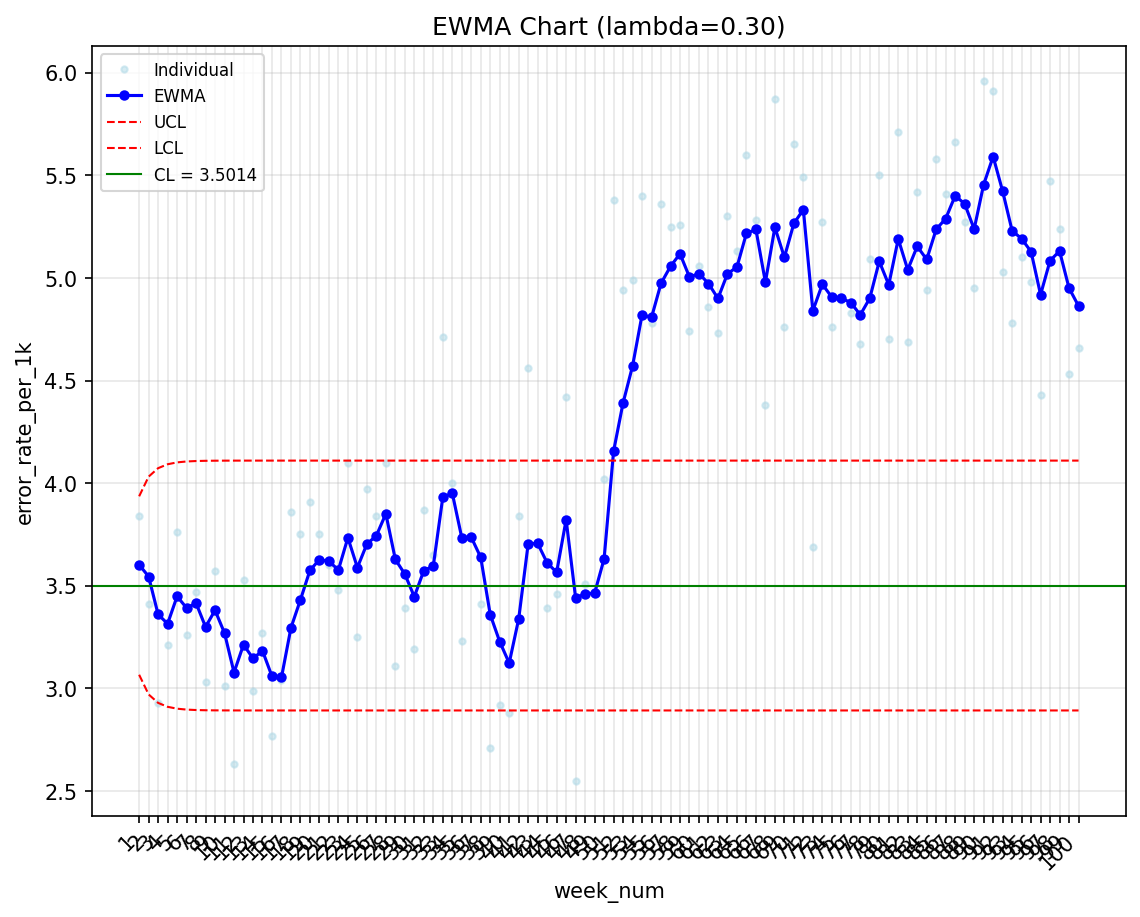

In [4]:
/* --------------------------------------------------------
   Fas II: övervaka hela 100-veckorsserien mot de fasta
   baslinjegränserna. lambda=0,3 ger snabb detektion,
   lämpligt för patientsäkerhetsövervakning.
   -------------------------------------------------------- */
PROCEDUR macontrol data=work.icu_errors limits=work.icu_limits;
    ewmachart error_rate_per_1k * week_num /
        weight    = 0.3
        sigmas    = 3
        readlimits
        outtable  = work.icu_table;
    ETIKETT error_rate_per_1k =
          "Läkemedelsfel per 1 000 administreringar";
    TITEL "EWMA-diagram: IVA-läkemedelsfelfrekvens (lambda=0,3)";
KÖR;

---

In [5]:
/* --------------------------------------------------------
   Identifiera varje vecka där EWMA överskrider baslinjens
   gränser och rapportera när diagrammet först signalerar.
   -------------------------------------------------------- */
data work.signals;
    STÄLL_IN work.icu_table;
    DÄR _EXLIM_ ne ' ' AND _EXLIM_ ne '0';
KÖR;

PROCEDUR SQL;
    VÄLJ count(*)        AS n_signals          ETIKETT="Signalveckor",
           MIN(week_num)    AS first_signal_week  ETIKETT="Första signalvecka",
           MAX(_EWMA_)      AS peak_ewma format=6.3 ETIKETT="Högsta EWMA-värde"
    FROM work.signals;
QUIT;

PROCEDUR SKRIV data=work.signals(obs=8);
    VARIABEL week_num error_rate_per_1k _EWMA_ _UCLE_ _EXLIM_;
    ETIKETT week_num="Vecka" error_rate_per_1k="Felfrekvens per 1 000"
          _EWMA_="EWMA" _UCLE_="Övre EWMA-gräns" _EXLIM_="Utanför gräns";
    TITEL "Första EWMA-signalerna utanför kontroll";
KÖR;

                                 Indata för fas I-kontrollgränser (baslinjeveckor 1-50)                                 

Signalveckor   Första signalvecka    Högsta EWMA-värde
------------  -------------------  -------------------
          50                 51.0                5.591
                                        Första EWMA-signalerna utanför kontroll                                         

  Obs  Vecka      EWMA    Övre EWMA-gräns    Utanför gräns
    1     51  4.155551            4.10998                1
    2     52  4.390886            4.10998                1
    3     53   4.57062            4.10998                1
    4     54  4.819434            4.10998                1
    5     55  4.807604            4.10998                1
    6     56  4.973323            4.10998                1
    7     57  5.056326            4.10998                1
    8     58  5.117428            4.10998                1

... 42 more observations (showing 8 of 50)




NOTE: DATA work.signals


NOTE: Read 100 rows from work.icu_table.
NOTE: Wrote work.signals (50 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.signals

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---

### Tolkning

Tvåfasanalysen med EWMA separerar tydligt vanlig veckovis variation från den verkliga processförändringen vid eMAR-driftsättningen.

**Baslinje (vecka 1-50).** PROC MEANS rapporterar en genomsnittlig baslinjefelfrekvens på **3,50 per 1 000 administreringar** (standardavvikelse 0,48), mot ett medelvärde efter migreringen på **5,11** (standardavvikelse 0,44) -- en varaktig uppåtgående förändring på cirka **1,6 fel per 1 000**. Administreringsvolymen är jämförbar mellan de två faserna (795 mot 790 per vecka), så förändringen speglar felfrekvensen, inte en svängning i arbetsbelastningen.

**Styrgränser.** Gränserna är fastställda enbart utifrån baslinjen: centrumlinje **3,5014**, baslinjesigma **0,4829**. Med utjämningsvikt lambda = 0,3 och 3-sigmagränser stabiliserar sig EWMA:s övre gräns vid sitt asymptotiska värde på cirka **4,11**. Under hela vecka 1-50 håller sig EWMA-statistiken inom dessa gränser -- baslinjen ger **noll falska larm**, vilket bekräftar att diagrammet inte är översensitivt.

**Detektion.** Diagrammet signalerar utom kontroll redan **den allra första veckan efter driftsättningen (vecka 51)**, där EWMA når **4,156**, strax över gränsen på 4,11. Från den punkten stiger statistiken stadigt och förblir över den övre gränsen under hela perioden efter migreringen: **samtliga 50 veckor efter migreringen (51-100) signalerar**, och EWMA når sitt högsta värde på **5,591** kring vecka 91. Responsiviteten hos lambda = 0,3 innebär att försämringen flaggas omedelbart istället för efter flera veckors ackumulering.

**Åtgärd.** Ett varaktigt EWMA-brott som börjar samma vecka som en eMAR-driftsättning är starkt belägg för att det nya systemet -- inte slumpen -- drev ökningen. Patientsäkerhetskommittén bör betrakta vecka 51 som förändringspunkten, granska de eMAR-arbetsflöden för läkemedelsordination och överstyrning som infördes den veckan, och fortsätta köra diagrammet mot de ursprungliga baslinjegränserna tills EWMA återgår under 4,11. De exporterade filerna `icu_ewma_signals.csv` (50 signalveckor) och `icu_ewma_table.csv` utgör det dokumenterade SPC-bevisspåret för Joint Commissions granskning av kontinuerlig beredskap.

---

In [6]:
/* --------------------------------------------------------
   Exportera EWMA-tabellen och signallistan för
   Joint Commission-dokumentation av kontinuerlig beredskap.
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=work.icu_table
    OUTFILE='icu_ewma_table.csv'
    DBMS=csv REPLACE;
KÖR;

PROCEDUR EXPORTERA data=work.signals
    OUTFILE='icu_ewma_signals.csv'
    DBMS=csv REPLACE;
KÖR;


NOTE: PROC EXPORT data=work.icu_table outfile=icu_ewma_table.csv

NOTE: Exported 100 rows to icu_ewma_table.csv.
NOTE: PROC EXPORT data=work.signals outfile=icu_ewma_signals.csv

NOTE: Exported 50 rows to icu_ewma_signals.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>